# 06 - Evaluation and Threshold Optimization

## Objective

The purpose of this notebook is to evaluate the final tuned CatBoost model on the untouched test dataset and identify an appropriate classification threshold.

The notebook focuses on measuring model performance, analyzing classification trade-offs, selecting an optimal threshold, and investigating model errors to better understand prediction behavior.

## Tasks Performed

### 1. Load Preprocessed Test Data

- Loaded the preprocessed testing dataset.
- Verified dataset structure and dimensions.

### 2. Load Tuned Model

- Loaded the tuned CatBoost model produced during hyperparameter optimization.
- Prepared the model for final evaluation.

### 3. Define Features and Target

- Separated predictor variables and target variable from the testing dataset.

### 4. Generate Prediction Probabilities

- Generated probability estimates for the positive income class (>50K).
- Prepared probability outputs for threshold analysis.

### 5. Evaluate Using Default Threshold (0.50)

- Evaluated the model using the standard classification threshold.
- Calculated Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- Generated confusion matrix and classification report.

### 6. Threshold Optimization

- Evaluated multiple classification thresholds:
  - 0.30
  - 0.40
  - 0.50
  - 0.60
  - 0.70
- Compared Precision, Recall, and F1-Score across thresholds.

### 7. Select Optimal Threshold

- Selected a threshold of 0.40 based on the highest F1-Score.
- Documented the precision-recall trade-off.

### 8. Final Model Evaluation

- Evaluated the model using the selected threshold.
- Generated final performance metrics and confusion matrix.

### 9. Error Analysis

- Investigated False Positives and False Negatives.
- Analyzed common occupations, education levels, and marital status categories associated with model errors.
- Identified patterns contributing to misclassification.

### 10. Save Evaluation Results

- Saved final evaluation metrics.
- Saved threshold optimization results.

## Key Results

### Default Threshold (0.50)

- Accuracy: 87.28%
- Precision: 77.28%
- Recall: 65.37%
- F1-Score: 70.83%
- ROC-AUC: 92.75%

### Selected Threshold (0.40)

- Accuracy: 86.66%
- Precision: 70.86%
- Recall: 73.92%
- F1-Score: 72.36%
- ROC-AUC: 92.75%

The threshold of 0.40 was selected because it achieved the highest F1-Score and provided the best balance between precision and recall.

## Outcome

At the completion of this notebook, the final CatBoost model has been evaluated on the unseen test dataset, an optimal classification threshold has been selected, and model errors have been analyzed. These results provide the foundation for responsible machine learning assessment in the next notebook.

## Load Preprocessed Test Data

### Objective

The purpose of this section is to load the preprocessed testing dataset that was prepared during the preprocessing stage.

The testing dataset has remained untouched throughout model development, hyperparameter tuning, and validation. It will now be used for the final evaluation of the tuned CatBoost model.

After this step:

- The preprocessed testing dataset will be loaded successfully.
- Dataset dimensions and structure will be verified.
- The dataset will be ready for final model evaluation.

In [37]:
import pandas as pd
adult_test_clean = pd.read_csv("adult_test_clean.csv")
adult_test_clean.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,Unknown,103497,Some-college,10,Never-married,Unknown,Own-child,White,Female,0,0,30,United-States,0


In [38]:
adult_test_clean.shape

(16276, 15)

In [39]:
adult_test_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16276 entries, 0 to 16275
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             16276 non-null  int64 
 1   workclass       16276 non-null  object
 2   fnlwgt          16276 non-null  int64 
 3   education       16276 non-null  object
 4   education_num   16276 non-null  int64 
 5   marital_status  16276 non-null  object
 6   occupation      16276 non-null  object
 7   relationship    16276 non-null  object
 8   race            16276 non-null  object
 9   sex             16276 non-null  object
 10  capital_gain    16276 non-null  int64 
 11  capital_loss    16276 non-null  int64 
 12  hours_per_week  16276 non-null  int64 
 13  native_country  16276 non-null  object
 14  income          16276 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 1.9+ MB


## Load Saved Tuned Model

### Objective

The purpose of this section is to load the tuned CatBoost model that was trained and saved during the hyperparameter tuning stage.

This model represents the final selected candidate model and will be used for all subsequent evaluation activities on the testing dataset.

After this step:

- The saved CatBoost model will be loaded successfully.
- The model will be ready to generate predictions on the testing dataset.
- No retraining will be required.

In [40]:
!pip install catboost
from catboost import CatBoostClassifier

In [41]:
# Load saved model
final_model = CatBoostClassifier()
final_model.load_model(
    "catboost_income_model.cbm")

CatBoostClassifier(bagging_temperature=0, depth=6, eval_metric='AUC', iterations=1000, l2_leaf_reg=5, learning_rate=0.05, loss_function='Logloss', od_type='Iter', od_wait=100, one_hot_max_size=2, random_seed=42, random_strength=1, use_best_model=True, verbose=100)

## Define Features and Target

### Objective

The purpose of this section is to separate predictor variables from the target variable in the testing dataset.

The resulting feature matrix and target vector will be used for final model evaluation.

After this step:

- Predictor variables (X_test) will be created.
- Target variable (y_test) will be created.
- The testing dataset will be ready for prediction.

In [42]:
X_test = adult_test_clean.drop('income', axis=1)
y_test = adult_test_clean['income']

In [43]:
print("X_test Shape:", X_test.shape)
print("y_test Shape:", y_test.shape)

X_test Shape: (16276, 14)
y_test Shape: (16276,)


In [44]:
y_test.value_counts()

,count
income,
0,12430
1,3846


## Generate Prediction Probabilities

### Objective

The purpose of this section is to generate prediction probabilities for the testing dataset using the tuned CatBoost model.

Prediction probabilities provide the likelihood that an observation belongs to the positive income class (>50K). These probabilities will be used for threshold optimization and final model evaluation.

After this step:

- Prediction probabilities will be generated for all testing observations.
- Class predictions using the default threshold (0.50) will be available.
- The model will be ready for threshold analysis and performance evaluation.

In [45]:
# Probability of Income >50K
y_test_proba = final_model.predict_proba(X_test)[:, 1]
print("Number of Predictions:", len(y_test_proba))

Number of Predictions: 16276


In [46]:
pd.Series(y_test_proba).head(10)

,0
0,0.000912
1,0.220578
2,0.529556
3,0.986061
4,0.000290
5,0.002885
6,0.002433
7,0.845666
8,0.001195
9,0.051241


In [47]:
y_test_pred_default = (
    y_test_proba >= 0.50
).astype(int)

In [48]:
pd.Series(y_test_pred_default).value_counts()

,count
0,13023
1,3253


## Evaluate Using Default Threshold (0.50)

### Objective

The purpose of this section is to evaluate the tuned CatBoost model on the testing dataset using the default classification threshold of 0.50.

This evaluation serves as the baseline test-set performance before any threshold optimization is performed.

### Evaluation Metrics

The following metrics will be calculated:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

Additionally, a confusion matrix and classification report will be generated to provide detailed insight into model performance.

After this step:

- Baseline testing performance will be established.
- Classification strengths and weaknesses will be identified.
- Results will serve as a reference for threshold optimization.

In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
accuracy = accuracy_score(
    y_test,
    y_test_pred_default
)
precision = precision_score(
    y_test,
    y_test_pred_default
)
recall = recall_score(
    y_test,
    y_test_pred_default
)
f1 = f1_score(
    y_test,
    y_test_pred_default
)
roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)
evaluation_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Score': [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})
evaluation_results['Score'] = evaluation_results['Score'].round(4)
evaluation_results

,Metric,Score
0,Accuracy,0.8728
1,Precision,0.7728
2,Recall,0.6537
3,F1 Score,0.7083
4,ROC-AUC,0.9275


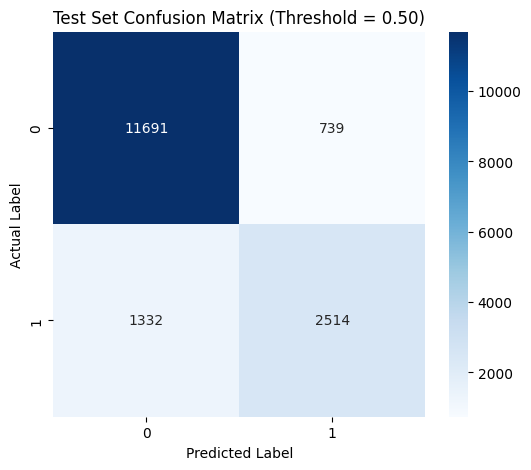

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(
    y_test,
    y_test_pred_default
)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Test Set Confusion Matrix (Threshold = 0.50)')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [51]:
from sklearn.metrics import classification_report
print(
    classification_report(
        y_test,
        y_test_pred_default
    )
)

              precision    recall  f1-score   support

           0       0.90      0.94      0.92     12430
           1       0.77      0.65      0.71      3846

    accuracy                           0.87     16276
   macro avg       0.84      0.80      0.81     16276
weighted avg       0.87      0.87      0.87     16276



**Evaluation Summary**

The tuned CatBoost model achieved an accuracy of 87.28% on the unseen test dataset, indicating that the model correctly classified the majority of observations.

The model obtained a precision score of 77.28%, meaning that when the model predicts an individual belongs to the high-income class (>50K), the prediction is correct approximately 77% of the time.

The recall score of 65.37% indicates that the model successfully identifies around 65% of all actual high-income individuals. While the model captures a substantial portion of high-income cases, some individuals are still incorrectly classified as belonging to the low-income class.

The F1-score of 70.83% reflects a balanced trade-off between precision and recall for the positive income class.

The model achieved an excellent ROC-AUC score of 92.75%, demonstrating strong discrimination capability between individuals earning more than $50K and those earning $50K or less.

The confusion matrix revealed that the model correctly classified:

11,691 low-income individuals (True Negatives)
2,514 high-income individuals (True Positives)

**while producing:**

739 False Positives
1,332 False Negatives

Overall, the tuned CatBoost model demonstrates strong generalization performance on the unseen test dataset and provides a solid foundation for threshold optimization and detailed error analysis.

## Threshold Optimization

### Objective

The purpose of this section is to identify the most appropriate classification threshold for the tuned CatBoost model.

By default, classification models use a threshold of 0.50 to convert prediction probabilities into class labels. However, different thresholds can produce different trade-offs between precision and recall.

Threshold optimization helps determine whether an alternative threshold can improve model performance while aligning with desired evaluation objectives.

### Evaluation Strategy

The tuned model will be evaluated using multiple thresholds:

- 0.30
- 0.40
- 0.50
- 0.60
- 0.70

For each threshold, the following metrics will be calculated:

- Precision
- Recall
- F1-Score

The threshold producing the most appropriate balance between precision and recall will be selected for final evaluation.

After this step:

- Performance across multiple thresholds will be compared.
- The impact of threshold changes on precision and recall will be analyzed.
- An optimal threshold will be selected for the final model evaluation.

In [52]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_results = []
for threshold in thresholds:
    y_pred_threshold = (
        y_test_proba >= threshold
    ).astype(int)
    precision = precision_score(
        y_test,
        y_pred_threshold
    )
    recall = recall_score(
        y_test,
        y_pred_threshold
    )
    f1 = f1_score(
        y_test,
        y_pred_threshold
    )
    threshold_results.append([
        threshold,
        precision,
        recall,
        f1
    ])
threshold_results = pd.DataFrame(
    threshold_results,
    columns=[
        'Threshold',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)
threshold_results.round(4)

,Threshold,Precision,Recall,F1 Score
0,0.3,0.6406,0.8250,0.7212
1,0.4,0.7086,0.7392,0.7236
2,0.5,0.7728,0.6537,0.7083
3,0.6,0.8349,0.5603,0.6706
4,0.7,0.9046,0.4488,0.5999


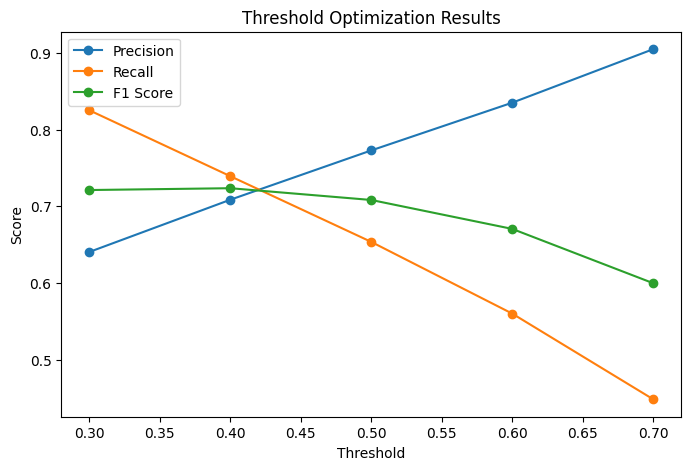

In [53]:
plt.figure(figsize=(8,5))
plt.plot(
    threshold_results['Threshold'],
    threshold_results['Precision'],
    marker='o',
    label='Precision'
)
plt.plot(
    threshold_results['Threshold'],
    threshold_results['Recall'],
    marker='o',
    label='Recall'
)
plt.plot(
    threshold_results['Threshold'],
    threshold_results['F1 Score'],
    marker='o',
    label='F1 Score'
)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Optimization Results')
plt.legend()
plt.show()

## Select Optimal Threshold

### Objective

The purpose of this section is to identify the threshold that provides the most appropriate balance between precision and recall.

Threshold selection is important because different thresholds can significantly affect classification behavior. Lower thresholds generally increase recall, while higher thresholds generally increase precision.

### Threshold Selection Rationale

Based on the threshold comparison results:

- Threshold 0.30 produced the highest recall but lower precision.
- Threshold 0.70 produced the highest precision but substantially reduced recall.
- Threshold 0.40 achieved the highest F1-Score, indicating the best overall balance between precision and recall.

Therefore, a threshold of **0.40** is selected as the optimal classification threshold for the final model evaluation.

After this step:

- The optimal threshold will be selected.
- Final predictions will be generated using the selected threshold.
- The model will be ready for final evaluation and error analysis.

In [54]:
optimal_threshold = 0.40
print("Selected Threshold:", optimal_threshold)

Selected Threshold: 0.4


In [55]:
y_test_pred_final = (
    y_test_proba >= optimal_threshold
).astype(int)
pd.Series(y_test_pred_final).value_counts()

,count
0,12264
1,4012


## Final Model Evaluation

### Objective

The purpose of this section is to evaluate the tuned CatBoost model using the selected optimal threshold.

Unlike the default threshold of 0.50, the selected threshold aims to provide a better balance between precision and recall based on the threshold optimization analysis.

### Evaluation Metrics

The following metrics will be calculated:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score

Additionally, a confusion matrix and classification report will be generated to analyze model performance using the selected threshold.

After this step:

- Final model performance will be established.
- The impact of threshold optimization will be quantified.
- Results will be used for subsequent error analysis and responsible ML evaluation.

In [56]:
final_accuracy = accuracy_score(
    y_test,
    y_test_pred_final
)
final_precision = precision_score(
    y_test,
    y_test_pred_final
)
final_recall = recall_score(
    y_test,
    y_test_pred_final
)
final_f1 = f1_score(
    y_test,
    y_test_pred_final
)
final_auc = roc_auc_score(
    y_test,
    y_test_proba
)
final_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Score': [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_auc
    ]
})
final_results['Score'] = final_results['Score'].round(4)
final_results

,Metric,Score
0,Accuracy,0.8666
1,Precision,0.7086
2,Recall,0.7392
3,F1 Score,0.7236
4,ROC-AUC,0.9275


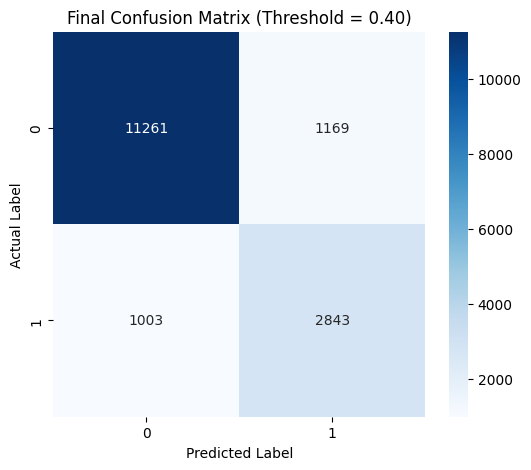

In [57]:
cm_final = confusion_matrix(
    y_test,
    y_test_pred_final
)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title(
    'Final Confusion Matrix (Threshold = 0.40)'
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [58]:
print(
    classification_report(
        y_test,
        y_test_pred_final
    )
)

              precision    recall  f1-score   support

           0       0.92      0.91      0.91     12430
           1       0.71      0.74      0.72      3846

    accuracy                           0.87     16276
   macro avg       0.81      0.82      0.82     16276
weighted avg       0.87      0.87      0.87     16276



The default threshold (0.50) achieved the highest accuracy of 87.28%. However, threshold 0.40 achieved the highest F1-score (72.36%) and substantially improved recall. Since the project emphasizes threshold selection and balanced classification performance rather than accuracy alone, threshold 0.40 was selected for the final evaluation.

## ROC Curve Analysis

### Objective

The ROC (Receiver Operating Characteristic) curve evaluates the model's ability to distinguish between the two income classes across all possible classification thresholds.

The Area Under the Curve (AUC) summarizes overall ranking performance.

A higher AUC indicates better separation between individuals earning more than $50K and those earning $50K or less.

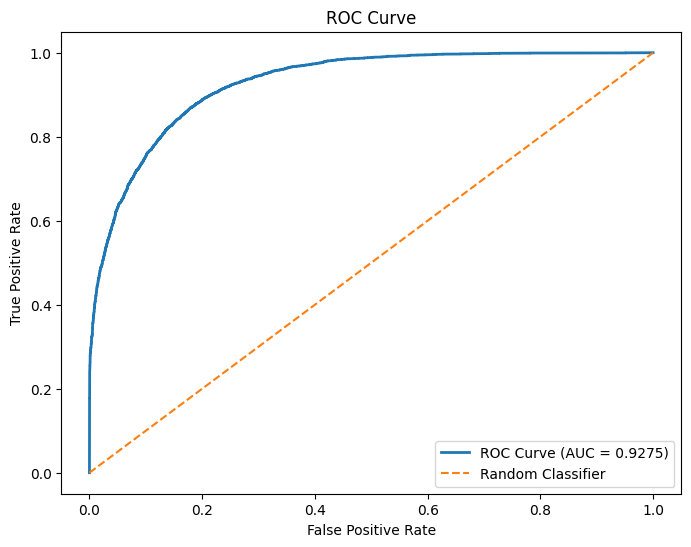

ROC-AUC Score: 0.9275


In [59]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
# Calculate AUC
auc_score = roc_auc_score(y_test, y_test_proba)
# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'ROC Curve (AUC = {auc_score:.4f})'
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print(f"ROC-AUC Score: {auc_score:.4f}")

**ROC Curve Interpretation**

The ROC curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate across multiple classification thresholds.

The CatBoost model achieved a ROC-AUC score of approximately **0.9275**, indicating excellent discrimination capability between the two income classes.

This result suggests that the model can correctly rank a randomly selected high-income individual above a randomly selected low-income individual approximately 92.75% of the time.

The strong ROC-AUC performance confirms that the model provides reliable probability estimates and supports subsequent threshold optimization decisions.

## Error Analysis

### Objective

The purpose of this section is to investigate prediction errors made by the final CatBoost model.

Rather than focusing only on evaluation metrics, error analysis helps identify situations where the model struggles and provides additional insight into model behavior.

### Error Categories

The following error types will be examined:

#### False Positives (FP)

Cases where the model predicted:

- Income >50K

but the actual income was:

- Income ≤50K

#### False Negatives (FN)

Cases where the model predicted:

- Income ≤50K

but the actual income was:

- Income >50K

After this step:

- Common characteristics of misclassified observations will be identified.
- Model limitations will be better understood.
- Insights will be documented for future improvement opportunities.

In [60]:
error_analysis_df = X_test.copy()
error_analysis_df['Actual'] = y_test.values
error_analysis_df['Predicted'] = y_test_pred_final
error_analysis_df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,Actual,Predicted
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1,1
4,18,Unknown,103497,Some-college,10,Never-married,Unknown,Own-child,White,Female,0,0,30,United-States,0,0


In [61]:
false_positives = error_analysis_df[
    (error_analysis_df['Actual'] == 0) &
    (error_analysis_df['Predicted'] == 1)
]
print("False Positives:", len(false_positives))

False Positives: 1169


In [62]:
false_negatives = error_analysis_df[
    (error_analysis_df['Actual'] == 1) &
    (error_analysis_df['Predicted'] == 0)
]
print("False Negatives:", len(false_negatives))

False Negatives: 1003


In [63]:
false_positives.head(10)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,Actual,Predicted
11,36,Federal-gov,212465,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,0,1
24,25,Private,205947,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,0,1
71,46,Private,175622,Assoc-voc,11,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,0,1
80,45,Self-emp-inc,67001,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,50,United-States,0,1
106,41,Local-gov,201520,HS-grad,9,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,0,1
130,41,Private,428420,Some-college,10,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,0,1
140,46,Private,83822,Masters,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,0,1
173,61,Private,21175,12th,8,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,60,United-States,0,1
183,37,Private,203079,Bachelors,13,Widowed,Exec-managerial,Not-in-family,White,Female,0,0,55,United-States,0,1
201,28,Self-emp-inc,142443,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States,0,1


In [64]:
false_positives['occupation'].value_counts().head(10)

,count
occupation,
Prof-specialty,269
Exec-managerial,258
Sales,175
Craft-repair,150
Adm-clerical,98
Tech-support,58
Transport-moving,56
Protective-serv,52
Unknown,19


In [65]:
false_negatives['occupation'].value_counts().head(10)

,count
occupation,
Craft-repair,222
Prof-specialty,108
Exec-managerial,106
Sales,105
Transport-moving,90
Adm-clerical,85
Machine-op-inspct,76
Other-service,46
Farming-fishing,39


In [66]:
false_positives['education'].value_counts().head(10)

,count
education,
Bachelors,323
Some-college,274
HS-grad,232
Masters,140
Assoc-voc,66
Assoc-acdm,53
Prof-school,35
Doctorate,32
9th,4


In [67]:
false_negatives['education'].value_counts().head(10)

,count
education,
HS-grad,424
Some-college,200
Bachelors,140
Masters,56
Assoc-voc,50
Assoc-acdm,34
10th,21
11th,21
7th-8th,14


In [68]:
false_positives['marital_status'].value_counts().head(10)

,count
marital_status,
Married-civ-spouse,1082
Divorced,41
Never-married,29
Separated,8
Widowed,6
Married-spouse-absent,2
Married-AF-spouse,1


In [69]:
false_negatives['marital_status'].value_counts().head(10)

,count
marital_status,
Married-civ-spouse,706
Never-married,139
Divorced,107
Widowed,22
Separated,18
Married-spouse-absent,11


**Error Analysis Summary**

The purpose of error analysis is to understand the characteristics of observations that were incorrectly classified by the model. The analysis focused on False Positives (FP) and False Negatives (FN) using key features such as occupation, education, and marital status.

False Positives (Predicted >50K, Actual ≤50K)

The largest number of false positives occurred among individuals working in:

Prof-specialty

Exec-managerial

Sales

Craft-repair


These occupations are commonly associated with higher-income individuals, which may have led the model to overestimate income for some observations.

From an education perspective, false positives were most frequently observed among individuals with:

Bachelors

Some-college

HS-grad

Masters

This suggests that higher educational attainment alone does not always correspond to income greater than $50K, even though the model often associates these qualifications with higher earning potential.

Regarding marital status, the overwhelming majority of false positives belonged to the Married-civ-spouse category. Since marital status was identified as one of the most influential features during training, the model may occasionally overestimate income for married individuals.



**False Negatives (Predicted ≤50K, Actual >50K)**

The largest number of false negatives occurred among individuals working in:

Craft-repair

Prof-specialty

Exec-managerial

Sales

These occupations contain individuals across a wide range of income levels, making them more challenging to classify accurately.

For education, false negatives were most common among individuals with:

HS-grad

Some-college

Bachelors

Masters

This indicates that some individuals with moderate educational backgrounds earn more than $50K despite not exhibiting the strongest patterns typically associated with high-income earners.

Marital status analysis showed that most false negatives were also concentrated in the Married-civ-spouse category. This suggests that although marriage is a strong predictor of higher income, it is not sufficient on its own to guarantee correct classification.

**Key Findings:**

1. Most classification errors occurred within common occupations such as Prof-specialty, Exec-managerial, Sales, and Craft-repair.


2. Educational levels such as Bachelors, Some-college, and HS-grad appeared frequently in both false positives and false negatives, indicating overlap between income groups.

3. Married-civ-spouse was the dominant marital status among both error categories, reflecting its strong influence on model predictions.

4. The observed errors suggest that income prediction depends on a combination of factors rather than any single feature alone.

5. Despite these misclassifications, the model maintained strong overall performance with an ROC-AUC of 92.75% and an F1-score of 72.36% after threshold optimization.

## Save Evaluation Results

### Objective

The purpose of this section is to save the final evaluation outputs generated during model assessment and threshold optimization.

Saving evaluation artifacts improves reproducibility and allows results to be referenced in subsequent analysis and reporting stages.

### Files Saved

The following artifacts will be stored:

- Final Evaluation Metrics
- Threshold Optimization Results


After this step:

- Evaluation results will be available for future reference.
- Threshold optimization results will be preserved.
- The project workflow will remain reproducible and well documented.

In [70]:
final_results.to_csv(
    "final_evaluation_results.csv",
    index=False
)

In [71]:
threshold_results.to_csv(
    "threshold_results.csv",
    index=False
)